# Plot Snyder free-parameter scan results

Assumes `scan_free_param_Snyder.py` has already been run. Reads
`scan_results_Snyder_N{N}/<eq_tag>/` (saved `ne_*.npy`, success/failure CSVs)
and compares converged profiles to the OMFITnc reference density for that
equilibrium. Set `eq_tag` below to choose which shot/time to plot.

In [1]:
import csv
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d

%matplotlib inline

HERE = Path.cwd()
ROOT = HERE.parent.parent.parent  # saarelma-conner-ped/
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(HERE))

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))

from scan_free_param_Snyder import (
    N,
    P_tot_e,
    Z_i,
    geqdsk_dir,
    kprof_loc,
    pfile_dir,
    scan_success_dir,
    species,
)
from src.load_equil import initialize_inputs
from src.solver_nondim import saarelma_connor_nondim

# Pick an equilibrium that already has scan output. Override eq_tag to plot another.
eq_dirs = sorted(p for p in scan_success_dir.iterdir() if p.is_dir())
if not eq_dirs:
    raise FileNotFoundError(
        f'No equilibrium dirs under {scan_success_dir}. '
        'Run scan_free_param_Snyder.py first.'
    )
print(f'Available equilibria ({len(eq_dirs)}):')
for p in eq_dirs[:10]:
    print(f'  {p.name}')
if len(eq_dirs) > 10:
    print(f'  ... and {len(eq_dirs) - 10} more')

eq_tag = eq_dirs[0].name  # <-- change this to plot a different equilibrium
scan_dir = scan_success_dir / eq_tag
success_fp = scan_dir / 'success_Snyder.txt'
failure_fp = scan_dir / 'failure_Snyder.txt'

# Filename keys: nc before n so ncx_x0_ratio is not parsed as n.
pattern = re.compile(r'_(nc|a|C|D|n|b)([0-9.eE+-]+)')

print(f'\neq_tag = {eq_tag}')
print(f'scan_dir = {scan_dir}')
print(f'npy files: {len(list(scan_dir.glob("ne_*.npy")))}')

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


Available equilibria (100):
  125729.03589
  125730.02445
  125731.02893
  125732.03508
  125761.03760
  125787.03894
  128398.04295
  128413.04088
  128572.03809
  128578.03658
  ... and 90 more

eq_tag = 125729.03589
scan_dir = /mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/SC_free_parameters/Snyder_database/scan_results_Snyder_N3/125729.03589
npy files: 191


In [2]:
# Resolve g / OMFITnc paths for this eq_tag and build a base model for the
# reference ne profile + x <-> psi_N map (same construction as the scan).
equil_num = len(list(pfile_dir.glob('*.cdf')))
equilibria = initialize_inputs(
    equil_num, geqdsk_dir, pfile_dir, p_filetype='OMFITnc',
)
matched = [(g, p) for g, p in equilibria if Path(g).name[1:] == eq_tag]
if not matched:
    raise KeyError(f'No g/OMFITnc pair found for eq_tag={eq_tag!r}')
mhd_fp, kprof_fp = matched[0]
print(f'g: {mhd_fp}')
print(f'p: {kprof_fp}')

ref = saarelma_connor_nondim(
    P_tot_e=P_tot_e,
    species=species,
    Z_i=Z_i,
    alpha_crit=0.1,
    C_KBM=0.1,
    De_chie_etg=0.1,
    nFC_x0=1e14,
    ncx_x0_ratio=1.259,
    psi_N_inner_boundary=0.85,
    mhd_fp=mhd_fp,
    kprof_fp=kprof_fp,
    kprof_loc=kprof_loc,
    verbose=False,
)

psi_ref = np.asarray(ref.psi_N_pres)
ne_ref = np.asarray(ref.n_e_pres)  # m^-3 on pressure grid

x_shift = ref.r_psi - ref.r_psi[-1]  # m, separatrix = 0
psi_to_x = interp1d(
    ref.psi_N_pres, x_shift,
    kind='linear', bounds_error=False, fill_value='extrapolate',
)
x_to_psi = interp1d(
    x_shift, ref.psi_N_pres,
    kind='linear', bounds_error=False, fill_value='extrapolate',
)

x_ref = psi_to_x(psi_ref)
print(f'OMFITnc ne max = {ne_ref.max():.3e} m^-3')
print(f'x_sep domain from map: [{x_shift.min():.4f}, {x_shift.max():.4f}] m')

Equilibrium found without match
Equilibrium found without match
Equilibrium found without match
Selected 302 g/OMFITnc file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125729.03589
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125729_3.55_3.65_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125730.02445
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125730_2.4_2.5_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125731.02893
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125731_2.825_2.925_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125732.03508
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125732_3.45_3.55_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125761.03760
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125761

# Single equilibria analysis

rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0  ncx_x0_ratio       L2 (m^-3)
-----------------------------------------------------------------------------------
   1         0.1       0.1            1      3.16e+15          4.73       6.594e+17
   2         0.1         1           10         1e+17          1.26       7.282e+17
   3           1         1           10         1e+17          1.26       1.225e+18
   4           1       0.1            1      3.16e+15          4.73       1.439e+18
   5           1       0.1          0.1      3.16e+15          1.26       1.601e+18
   6         0.1        10           10         1e+17          4.73       1.667e+18
   7          10       0.1          0.1         1e+14          17.8       1.813e+18
   8          10         1          0.1         1e+14          17.8       1.813e+18
   9          10        10          0.1         1e+14          17.8       1.813e+18
  10         0.1         1            1      3.16e+15          17.8       1.

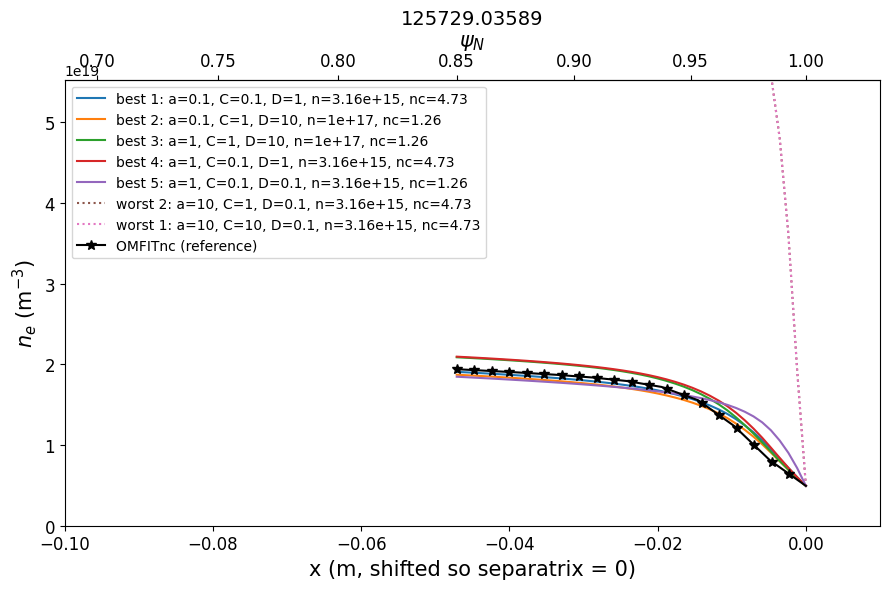

In [3]:
# Rank successful runs by L2 distance to OMFITnc ne on a common pedestal grid,
# then plot top 5 (solid) and worst 2 (dotted) vs OMFITnc.

psi_ped = np.linspace(0.85, 1.0, 200)
x_ped = psi_to_x(psi_ped)

ne_ref_ped = interp1d(
    psi_ref, ne_ref, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)(psi_ped)
ne_ref_of_x = interp1d(
    x_ref, ne_ref, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)

def _sol_xy(sol):
    """Scan saves a dict {'x', 'y', ...}; y is 1-D ne."""
    if isinstance(sol, dict):
        return np.asarray(sol['x']), np.asarray(sol['y'])
    y = sol.y[0] if np.ndim(sol.y) > 1 else sol.y
    return np.asarray(sol.x), np.asarray(y)


results_l2 = []
for npy_path in scan_dir.glob('ne_*.npy'):
    pairs = pattern.findall(npy_path.stem)
    params = {key: float(num) for key, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    sol_x, sol_ne = _sol_xy(sol)
    ne_pred_ped = interp1d(
        sol_x, sol_ne, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(x_ped)
    l2 = np.sqrt(np.mean((ne_pred_ped - ne_ref_ped) ** 2))  # RMS in m^-3
    results_l2.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'ncx_x0_ratio': params.get('nc'),
        'l2':          l2,
        'sol_x':       sol_x,
        'sol_ne':      sol_ne,
    })

if not results_l2:
    raise FileNotFoundError(f'No ne_*.npy under {scan_dir}')

results_l2.sort(key=lambda r: r['l2'])

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'ncx_x0_ratio':>12}  {'L2 (m^-3)':>14}")
print(header)
print('-' * len(header))
for rank, r in enumerate(results_l2, start=1):
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  "
          f"{r['ncx_x0_ratio']:>12.3g}  {r['l2']:>14.3e}")


def _label(r):
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            f"nc={r['ncx_x0_ratio']:.3g}")


fig, ax = plt.subplots(figsize=(9, 6))
for i, r in enumerate(results_l2[:5]):
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f'best {i+1}: {_label(r)}')
for i, r in enumerate(results_l2[-2:]):
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f'worst {2-i}: {_label(r)}')

plotted = results_l2[:5] + results_l2[-2:]
x_lo = min(r['sol_x'].min() for r in plotted)
x_hi = max(r['sol_x'].max() for r in plotted)
x_exp = np.linspace(x_lo, x_hi, 400)
ax.plot(x_exp, ne_ref_of_x(x_exp), '-*', color='black', markevery=20,
        markersize=7, label='OMFITnc (reference)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.set_title(f'{eq_tag}', fontsize=14)
ax.legend(fontsize=10, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0, 1.2 * float(ne_ref.max()))
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.show()

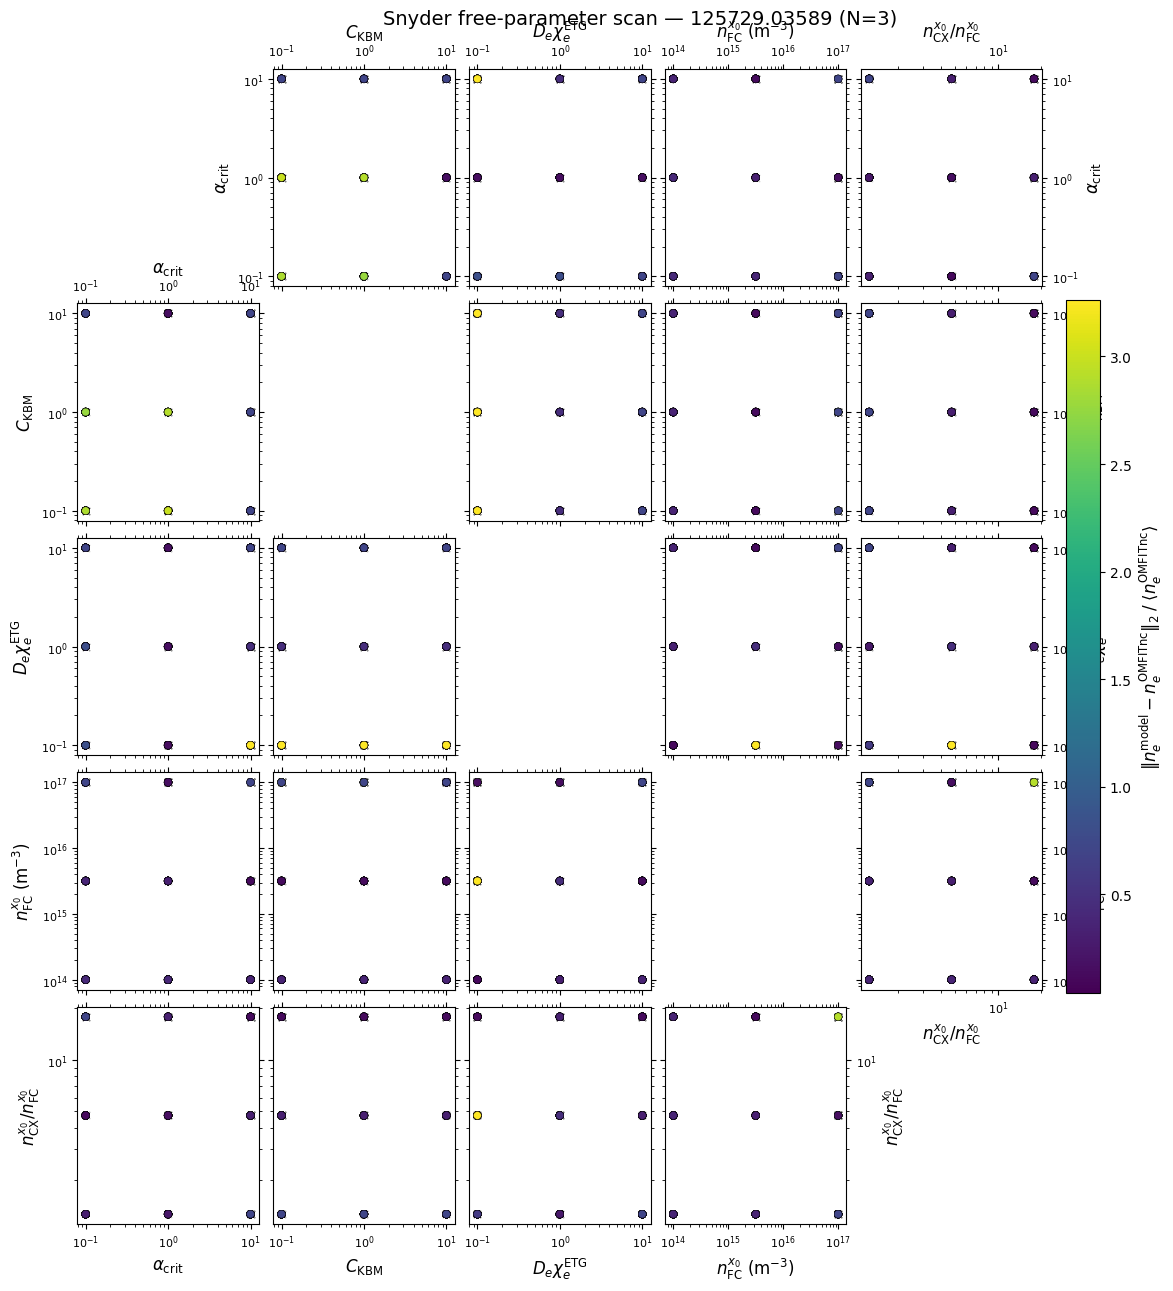

successes plotted: 191, failures: 52


In [4]:
# 5x5 panel plot over the five scanned free parameters for this equilibrium.
# Off-diagonal: all combinations projected onto a 2D (param_x, param_y) slice.
# Successes: colored by normalized L2 to OMFITnc ne. Failures: grey x markers.

psi_ped_grid = np.linspace(0.85, 1.0, 200)
x_ped_grid = psi_to_x(psi_ped_grid)
ne_ref_on_ped = interp1d(
    psi_ref, ne_ref, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)(psi_ped_grid)
mean_ne_ref = float(np.mean(ne_ref_on_ped))

success_records = []  # a, C, D, n, nc, L2/mean_ne
for npy_path in scan_dir.glob('ne_*.npy'):
    pairs = pattern.findall(npy_path.stem)
    params = {key: float(num) for key, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    sol_x, sol_ne = _sol_xy(sol)
    ne_pred_on_ped = interp1d(
        sol_x, sol_ne, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(x_ped_grid)
    l2 = np.sqrt(np.mean((ne_pred_on_ped - ne_ref_on_ped) ** 2))
    success_records.append((
        params.get('a'), params.get('C'), params.get('D'),
        params.get('n'), params.get('nc'), l2 / mean_ne_ref,
    ))
success_arr = np.array(success_records)

# failure_Snyder.txt: eq_tag, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner
failure_records = []
with open(failure_fp, newline='') as f:
    reader = csv.reader(f)
    next(reader)  # header
    for row in reader:
        failure_records.append([float(x.strip()) for x in row[1:6]])
failure_arr = np.array(failure_records) if failure_records else np.empty((0, 5))

panel_labels = [r'$\alpha_{\mathrm{crit}}$',
                r'$C_{\mathrm{KBM}}$',
                r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                r'$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)',
                r'$n_{\mathrm{CX}}^{x_0}/n_{\mathrm{FC}}^{x_0}$']
log_axis = [True, True, True, True, True]

norm = Normalize(vmin=float(success_arr[:, 5].min()),
                 vmax=float(success_arr[:, 5].max()))
cmap = plt.get_cmap('viridis')

fig, axes = plt.subplots(5, 5, figsize=(15, 15),
                         gridspec_kw=dict(wspace=0.08, hspace=0.08))

for row in range(5):
    for col in range(5):
        ax = axes[row, col]
        if row == col:
            ax.set_visible(False)
            continue

        if failure_arr.size:
            ax.scatter(failure_arr[:, col], failure_arr[:, row],
                       marker='x', color='gray', alpha=0.35, s=28,
                       linewidths=1.0)
        sc = ax.scatter(success_arr[:, col], success_arr[:, row],
                        c=success_arr[:, 5], cmap=cmap, norm=norm,
                        marker='o', s=32, edgecolors='black', linewidths=0.3)

        if log_axis[col]:
            ax.set_xscale('log')
        if log_axis[row]:
            ax.set_yscale('log')

        top_visible_row = 0 if col != 0 else 1
        bottom_visible_row = 4 if col != 4 else 3
        show_top_x = row == top_visible_row
        show_bottom_x = row == bottom_visible_row

        if show_bottom_x:
            ax.set_xlabel(panel_labels[col], fontsize=12)
            ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
        else:
            ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)

        if show_top_x:
            ax.xaxis.set_label_position('top')
            ax.tick_params(axis='x', which='both', top=True, labeltop=True)
            if not show_bottom_x:
                ax.set_xlabel(panel_labels[col], fontsize=12)
        else:
            ax.tick_params(axis='x', which='both', top=True, labeltop=False)

        left_visible_col = 0 if row != 0 else 1
        right_visible_col = 4 if row != 4 else 3
        show_left_y = col == left_visible_col
        show_right_y = col == right_visible_col

        if show_left_y:
            ax.set_ylabel(panel_labels[row], fontsize=12)
            ax.tick_params(axis='y', which='both', left=True, labelleft=True)
        else:
            ax.tick_params(axis='y', which='both', left=True, labelleft=False)

        if show_right_y:
            ax.yaxis.set_label_position('right')
            ax.tick_params(axis='y', which='both', right=True, labelright=True)
            if not show_left_y:
                ax.set_ylabel(panel_labels[row], fontsize=12)
        else:
            ax.tick_params(axis='y', which='both', right=True, labelright=False)

        ax.tick_params(axis='y', which='both', labelsize=8)
        ax.tick_params(axis='x', which='both', labelsize=8)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical',
                    shrink=0.6, pad=0.02)
cbar.set_label(
    r'$\|n_e^{\mathrm{model}} - n_e^{\mathrm{OMFITnc}}\|_2 \;/\; '
    r'\langle n_e^{\mathrm{OMFITnc}}\rangle$',
    fontsize=12,
)
fig.suptitle(f'Snyder free-parameter scan — {eq_tag} (N={N})', fontsize=14, y=0.92)
plt.show()

print(f'successes plotted: {len(success_arr)}, failures: {len(failure_arr)}')

# Multi-equilibria analysis

Across all equilibria with scan output under `scan_results_Snyder_N{N}/`.
Uses the scan's normalized L2 (`||ne_model - ne_ref|| / ||ne_ref||` on the solution grid)
and OMFITnc kinetic profiles as the experimental reference.


In [6]:
# Multi-eq setup: thresholds + equilibria list matching scan outputs
from collections import defaultdict
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

err_frac = 0.50          # normalized L2 cut for a "good" run
perc_success = 0.70      # combo must pass on this fraction of equilibria
bc_type = "neumann"      # matches scan_free_param_Snyder SOLVE_KW
psi_val_scan = 0.85
N_PARAM_COMBOS = int(N) ** 5
success_fp = Path("success_Snyder.txt")

# Equilibria that have scan results on disk
available_tags = {p.name for p in eq_dirs}
equil_num_all = len(list(pfile_dir.glob("*.cdf")))
all_pairs = initialize_inputs(
    equil_num_all, geqdsk_dir, pfile_dir, p_filetype="OMFITnc",
)
equilibria = [
    (g, p) for g, p in all_pairs if Path(g).name[1:] in available_tags
]
print(f"Multi-eq analysis over {len(equilibria)} / {len(available_tags)} "
      f"scanned equilibria (N_PARAM_COMBOS={N_PARAM_COMBOS})")


def param_key(ac, ck, de, nf, nc):
    return (round(float(ac), 3), round(float(ck), 3),
            round(float(de), 3), round(float(nf), 3), round(float(nc), 3))


def ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b=psi_val_scan):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{float(psi_b):.4f}.npy"
    )


def read_omfitnc_ne(kprof_fp):
    """Return (psi_N, ne [m^-3]) via the same OMFITnc loader as the solver."""
    psi_N, _Te, ne = saarelma_connor_nondim.OMFITnc_load(object(), str(kprof_fp))
    return np.asarray(psi_N, dtype=float), np.asarray(ne, dtype=float)


def omfitnc_ne_at_psi(kprof_fp, psi_n):
    psi_arr, ne_arr = read_omfitnc_ne(kprof_fp)
    return float(interp1d(
        psi_arr, ne_arr, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(psi_n))


def value_at_psi(x_grid, y_grid, x_at):
    return float(interp1d(
        x_grid, y_grid, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(x_at))


Equilibrium found without match
Equilibrium found without match
Equilibrium found without match
Selected 302 g/OMFITnc file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125729.03589
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125729_3.55_3.65_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125730.02445
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125730_2.4_2.5_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125731.02893
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125731_2.825_2.925_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125732.03508
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125732_3.45_3.55_.cdf
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125761.03760
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125761

In [7]:
# Rank all free-parameter combinations best → worst by mean normalized L2
# (averaged over equilibria where that combo converged). Also report coverage.

PARAM_NAMES = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")
combo_l2 = defaultdict(list)  # key -> list of L2 over eqs that converged

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, _psi_b, l2 = [x.strip() for x in row[:8]]
            key = param_key(ac, ck, de, nf, nc)
            combo_l2[key].append(float(l2))

n_eq = len(equilibria)
ranked_combos = []
for key, l2s in combo_l2.items():
    ranked_combos.append({
        "params": dict(zip(PARAM_NAMES, key)),
        "key": key,
        "mean_L2": float(np.mean(l2s)),
        "median_L2": float(np.median(l2s)),
        "max_L2": float(np.max(l2s)),
        "n_eq_converged": len(l2s),
        "coverage": len(l2s) / n_eq,
    })
ranked_combos.sort(key=lambda d: (d["mean_L2"], -d["coverage"]))

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'ncx_x0_ratio':>12}  {'mean_L2':>10}  "
          f"{'med_L2':>10}  {'max_L2':>10}  {'cov':>7}")
print("Free-parameter combinations ranked by mean normalized L2 "
      "(best → worst; coverage = fraction of equilibria that converged):")
print(header)
print("-" * len(header))
for i, d in enumerate(ranked_combos, start=1):
    p = d["params"]
    print(f"{i:>4}  {p['alpha_crit']:>10.3g}  {p['C_KBM']:>8.3g}  "
          f"{p['De_chie_etg']:>11.3g}  {p['nFC_x0']:>12.3g}  "
          f"{p['ncx_x0_ratio']:>12.3g}  {d['mean_L2']:>10.4f}  "
          f"{d['median_L2']:>10.4f}  {d['max_L2']:>10.4f}  "
          f"{d['coverage']:>6.1%}")
print(f"\nTotal unique converged combinations: {len(ranked_combos)} / {N_PARAM_COMBOS}")


Free-parameter combinations ranked by mean normalized L2 (best → worst; coverage = fraction of equilibria that converged):
rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0  ncx_x0_ratio     mean_L2      med_L2      max_L2      cov
----------------------------------------------------------------------------------------------------------------
   1         0.1        10            1         1e+17          4.73      0.1857      0.1774      0.6265  100.0%
   2         0.1         1          0.1      3.16e+15          17.8      0.1912      0.1746      0.6625  100.0%
   3           1        10            1         1e+17          4.73      0.1973      0.1750      0.6868   95.0%
   4           1        10          0.1         1e+17          1.26      0.2066      0.1684      1.6143   82.0%
   5           1         1          0.1      3.16e+15          4.73      0.2178      0.1907      0.4954  100.0%
   6         0.1        10          0.1         1e+17          4.73      0.2184      0.1795

In [8]:
# Filter runs with L2 < err_frac, then keep combos that pass on >= perc_success of eqs

filtered_runs = {}
good_runs_all = []
n_success_total = n_kept_total = 0

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    eq_dir = scan_success_dir / eq_tag
    success_path = eq_dir / success_fp
    if not success_path.exists():
        continue

    eq_runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            n_success_total += 1
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = map(float, (ac, ck, de, nf, nc))
            psi_b, l2 = float(psi_b), float(l2)
            if l2 >= err_frac:
                continue
            npy_path = ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            run = dict(
                eq_tag=eq_tag, mhd_fp=mhd_fp, kprof_fp=kprof_fp,
                alpha_crit=ac, C_KBM=ck, De_chie_etg=de,
                nFC_x0=nf, ncx_x0_ratio=nc, psi_N_inner=psi_b,
                norm_L2_error=l2,
                x=np.asarray(sol["x"], dtype=float),
                ne=np.asarray(sol["y"], dtype=float),
                npy_path=str(npy_path),
            )
            eq_runs.append(run)
            good_runs_all.append(run)
            n_kept_total += 1
    if eq_runs:
        filtered_runs[eq_tag] = eq_runs

print(f"Loaded {n_kept_total} / {n_success_total} successful runs "
      f"with err_frac < {err_frac:g}")
print(f"Equilibria with at least one good run: "
      f"{len(filtered_runs)} / {len(equilibria)}")

# Robust combinations: pass L2 cut on >= perc_success of all equilibria
combo_stats = defaultdict(list)
for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            key = param_key(ac, ck, de, nf, nc)
            l2 = float(l2)
            combo_stats[key].append(dict(
                eq_tag=eq_tag, norm_L2_error=l2, passed=l2 < err_frac,
            ))

n_equilibria_total = len(equilibria)
filtered_combos = {}
for key, outcomes in combo_stats.items():
    n_pass = sum(1 for o in outcomes if o["passed"])
    success_fraction = n_pass / n_equilibria_total
    if success_fraction < perc_success:
        continue
    runs = [
        r for r in good_runs_all
        if param_key(r["alpha_crit"], r["C_KBM"], r["De_chie_etg"],
                     r["nFC_x0"], r["ncx_x0_ratio"]) == key
    ]
    passing_eq_tags = {o["eq_tag"] for o in outcomes if o["passed"]}
    filtered_combos[key] = dict(
        params=dict(zip(PARAM_NAMES, key)),
        n_equilibria_passing=n_pass,
        n_equilibria_total=n_equilibria_total,
        success_fraction=success_fraction,
        per_equilibrium=outcomes,
        passing_eq_tags=sorted(passing_eq_tags),
        runs=runs,
        mean_err_frac=float(np.mean([o["norm_L2_error"] for o in outcomes if o["passed"]])),
        max_err_frac=float(np.max([o["norm_L2_error"] for o in outcomes if o["passed"]])),
    )

print(f"\nKept {len(filtered_combos)} / {len(combo_stats)} parameter combinations "
      f"with success_fraction >= {perc_success:g} "
      f"({perc_success * 100:.0f}% of {n_equilibria_total} equilibria)")
if filtered_combos:
    print("\nRobust combinations (by success_fraction, then mean L2):")
    for i, (_, combo) in enumerate(
        sorted(filtered_combos.items(),
               key=lambda item: (-item[1]["success_fraction"], item[1]["mean_err_frac"])),
        start=1,
    ):
        params = combo["params"]
        param_text = ", ".join(f"{name}={params[name]:g}" for name in PARAM_NAMES)
        print(
            f"  {i}. {param_text}; "
            f"pass={combo['n_equilibria_passing']}/{combo['n_equilibria_total']}, "
            f"success_fraction={combo['success_fraction']:.3f}, "
            f"mean_err_frac={combo['mean_err_frac']:.4f}, "
            f"max_err_frac={combo['max_err_frac']:.4f}"
        )
else:
    print("No combinations met perc_success — try lowering perc_success or err_frac.")


Loaded 17197 / 22386 successful runs with err_frac < 0.5
Equilibria with at least one good run: 100 / 100

Kept 189 / 241 parameter combinations with success_fraction >= 0.7 (70% of 100 equilibria)

Robust combinations (by success_fraction, then mean L2):
  1. alpha_crit=1, C_KBM=1, De_chie_etg=0.1, nFC_x0=3.16228e+15, ncx_x0_ratio=4.732; pass=100/100, success_fraction=1.000, mean_err_frac=0.2178, max_err_frac=0.4954
  2. alpha_crit=0.1, C_KBM=1, De_chie_etg=0.1, nFC_x0=3.16228e+15, ncx_x0_ratio=4.732; pass=100/100, success_fraction=1.000, mean_err_frac=0.2523, max_err_frac=0.4933
  3. alpha_crit=0.1, C_KBM=10, De_chie_etg=1, nFC_x0=1e+17, ncx_x0_ratio=4.732; pass=99/100, success_fraction=0.990, mean_err_frac=0.1813, max_err_frac=0.4654
  4. alpha_crit=0.1, C_KBM=1, De_chie_etg=0.1, nFC_x0=3.16228e+15, ncx_x0_ratio=17.783; pass=99/100, success_fraction=0.990, mean_err_frac=0.1864, max_err_frac=0.4798
  5. alpha_crit=0.1, C_KBM=10, De_chie_etg=0.1, nFC_x0=1e+17, ncx_x0_ratio=1.259; pass

Loaded 18792 converged runs across 189 kept combos and 100 equilibria; 108 (combo, eq) pairs had no saved run and were skipped.


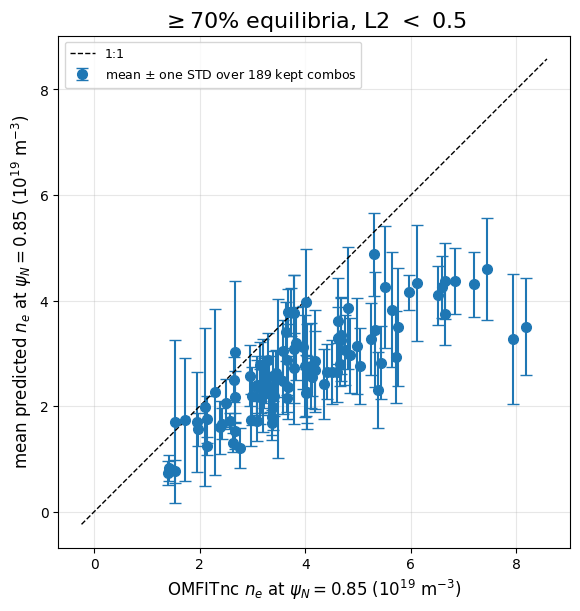

Plotted 100 / 100 equilibria using 189 kept combinations (quantity: ne)


In [9]:
# Mean ± std of predicted n_e at psi_N_plot over filtered_combos, vs OMFITnc

psi_N_plot = 0.85

if bc_type == "neumann":
    plot_quantity = "ne"
elif bc_type == "dirichlet":
    plot_quantity = "dne_dx"
else:
    raise ValueError(f"bc_type must be 'neumann' or 'dirichlet', got {bc_type!r}")

if not filtered_combos:
    print("No robust combinations in filtered_combos — run the previous cell first.")
else:
    combo_runs_by_eq = defaultdict(list)
    n_kept_combos = len(filtered_combos)
    n_runs_loaded = 0
    n_combos_missing_for_eq = 0

    for combo_key in filtered_combos:
        ac, ck, de, nf, nc = combo_key
        for mhd_fp, _ in equilibria:
            eq_tag = Path(mhd_fp).name[1:]
            npy_path = ne_npy_path(eq_tag, ac, ck, de, nf, nc)
            if not npy_path.exists():
                n_combos_missing_for_eq += 1
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            combo_runs_by_eq[eq_tag].append({
                "x": np.asarray(sol["x"], dtype=float),
                "ne": np.asarray(sol["y"], dtype=float),
            })
            n_runs_loaded += 1

    print(
        f"Loaded {n_runs_loaded} converged runs across {n_kept_combos} kept combos "
        f"and {len(equilibria)} equilibria; "
        f"{n_combos_missing_for_eq} (combo, eq) pairs had no saved run and were skipped."
    )

    omfit_cache = {}
    geometry_cache = {}
    ref_pts, pred_mean_pts, pred_std_pts, eq_labels, skipped = [], [], [], [], []

    for mhd_fp, kprof_fp in equilibria:
        eq_tag = Path(mhd_fp).name[1:]
        runs = combo_runs_by_eq.get(eq_tag, [])
        if not runs:
            skipped.append(eq_tag)
            continue

        if plot_quantity == "ne":
            # Scan used psi_N_inner = psi_val_scan → sample at the inner-boundary x
            x_at_psi = min(float(r["x"].min()) for r in runs)

            if kprof_fp not in omfit_cache:
                omfit_cache[kprof_fp] = read_omfitnc_ne(kprof_fp)
            psi_ref, ne_omfit = omfit_cache[kprof_fp]
            ref_val = float(interp1d(
                psi_ref, ne_omfit, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(psi_N_plot))
            pred_vals = [value_at_psi(r["x"], r["ne"], x_at_psi) for r in runs]
        else:
            if eq_tag not in geometry_cache:
                ref = saarelma_connor_nondim(
                    P_tot_e=P_tot_e, species=species, Z_i=Z_i,
                    alpha_crit=0.1, C_KBM=0.1, De_chie_etg=0.1,
                    nFC_x0=1e16, ncx_x0_ratio=1.0,
                    mhd_fp=mhd_fp, kprof_fp=kprof_fp, kprof_loc=kprof_loc,
                    verbose=False,
                )
                ref.setup_solver_grids(res=40)
                geometry_cache[eq_tag] = ref
            ref = geometry_cache[eq_tag]
            psi_to_x = interp1d(
                ref.psi_N_pres, ref.x_init,
                kind="linear", bounds_error=False, fill_value="extrapolate",
            )
            x_at_psi = float(psi_to_x(psi_N_plot))
            dne_dx_ref = np.gradient(ref.n_e_pres, ref.x_init)
            ref_val = value_at_psi(ref.x_init, dne_dx_ref, x_at_psi)
            pred_vals = [
                value_at_psi(r["x"], np.gradient(r["ne"], r["x"]), x_at_psi)
                for r in runs
            ]

        ref_pts.append(ref_val)
        pred_mean_pts.append(float(np.mean(pred_vals)))
        pred_std_pts.append(float(np.std(pred_vals)))
        eq_labels.append(eq_tag)

    if not ref_pts:
        print("No data to plot — check filtered_combos and psi_N_plot.")
        if skipped:
            print(f"Skipped equilibria (no kept combo converged): {skipped}")
    else:
        ref_pts = np.array(ref_pts)
        pred_mean_pts = np.array(pred_mean_pts)
        pred_std_pts = np.array(pred_std_pts)

        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
        if plot_quantity == "ne":
            x_plot = ref_pts / 1e19
            y_plot = pred_mean_pts / 1e19
            yerr = pred_std_pts / 1e19
            xlabel = rf"OMFITnc $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            ylabel = rf"mean predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
        else:
            x_plot = ref_pts
            y_plot = pred_mean_pts
            yerr = pred_std_pts
            xlabel = rf"OMFITnc $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            ylabel = rf"mean predicted $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"

        ax.errorbar(
            x_plot, y_plot, yerr=yerr,
            fmt="o", ms=7, capsize=4, lw=1.5,
            label=f"mean $\pm$ one STD over {n_kept_combos} kept combos",
        )
        lo = min(x_plot.min(), (y_plot - yerr).min())
        hi = max(x_plot.max(), (y_plot + yerr).max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="1:1")
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            rf"$\geq${perc_success*100:.0f}% equilibria, L2 $<$ {err_frac}",
            fontsize=16,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect("equal", adjustable="box")
        plt.show()
        print(
            f"Plotted {len(eq_labels)} / {len(equilibria)} equilibria "
            f"using {n_kept_combos} kept combinations (quantity: {plot_quantity})"
        )
        if skipped:
            print(f"Skipped (no kept combo converged): {skipped}")


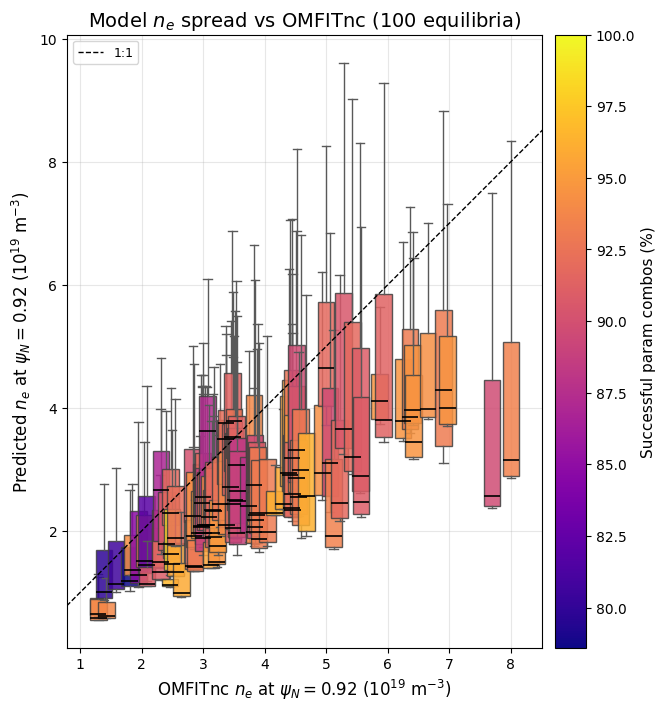

Plotted 100 equilibria
Success % range: 78.6% – 98.8%


In [10]:
# Box-and-whiskers: one box per equilibrium.
# y = model n_e over all converged param combos; x = OMFITnc n_e at psi_N_plot.
# Box color = n_succeeded / N_PARAM_COMBOS.

psi_N_plot = 0.92

omfit_cache = {}
geometry_cache = {}
boxes_y = []
ref_x = []
success_pct = []
eq_labels = []

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    if kprof_fp not in omfit_cache:
        omfit_cache[kprof_fp] = omfitnc_ne_at_psi(kprof_fp, psi_N_plot)
    ne_ref = omfit_cache[kprof_fp]

    if eq_tag not in geometry_cache:
        ref = saarelma_connor_nondim(
            P_tot_e=P_tot_e, species=species, Z_i=Z_i,
            alpha_crit=0.1, C_KBM=0.1, De_chie_etg=0.1,
            nFC_x0=1e16, ncx_x0_ratio=1.0,
            mhd_fp=mhd_fp, kprof_fp=kprof_fp, kprof_loc=kprof_loc,
            verbose=False,
        )
        ref.setup_solver_grids(res=40)
        geometry_cache[eq_tag] = ref
    ref = geometry_cache[eq_tag]
    x_at_psi = float(interp1d(
        ref.psi_N_pres, ref.x_init,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_N_plot))

    pred_ne = []
    succeeded_combos = set()
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, _l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = map(float, (ac, ck, de, nf, nc))
            key = param_key(ac, ck, de, nf, nc)
            succeeded_combos.add(key)
            psi_b = float(psi_b)
            npy_path = ne_npy_path(eq_tag, *key, psi_b)
            if not npy_path.exists():
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            x_sol = np.asarray(sol["x"], dtype=float)
            ne_sol = np.asarray(sol["y"], dtype=float)
            pred_ne.append(value_at_psi(x_sol, ne_sol, x_at_psi))

    if not pred_ne:
        continue

    boxes_y.append(np.asarray(pred_ne, dtype=float))
    ref_x.append(ne_ref)
    success_pct.append(100.0 * len(succeeded_combos) / N_PARAM_COMBOS)
    eq_labels.append(eq_tag)

if not boxes_y:
    print("No data to plot — check scan_success_dir and success logs.")
else:
    scale = 1e19
    ref_x = np.asarray(ref_x)
    success_pct = np.asarray(success_pct)

    order = np.argsort(ref_x)
    ref_x = ref_x[order] / scale
    boxes_y = [boxes_y[i] / scale for i in order]
    success_pct = success_pct[order]
    eq_labels = [eq_labels[i] for i in order]

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    cmap = cm.plasma
    norm = Normalize(vmin=success_pct.min(), vmax=100.0)

    xspan = max(ref_x.max() - ref_x.min(), 0.1)
    box_width = 0.04 * xspan

    bp = ax.boxplot(
        boxes_y, positions=ref_x, widths=box_width,
        patch_artist=True, showfliers=False, whis=1.5,
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="0.35", linewidth=1.0),
        capprops=dict(color="0.35", linewidth=1.0),
    )
    for patch, pct in zip(bp["boxes"], success_pct):
        patch.set_facecolor(cmap(norm(pct)))
        patch.set_alpha(0.85)
        patch.set_edgecolor("0.25")

    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Successful param combos (%)", fontsize=11)

    ax.set_xlabel(
        rf"OMFITnc $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_ylabel(
        rf"Predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_title(
        rf"Model $n_e$ spread vs OMFITnc ({len(boxes_y)} equilibria)",
        fontsize=14,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    plt.show()

    print(f"Plotted {len(boxes_y)} equilibria")
    print(f"Success % range: {success_pct.min():.1f}% – {success_pct.max():.1f}%")


Parsed 100 equilibria and 22386 total runs.
Dynamically discovered parameter grids:
  $\alpha_{crit}$: [0.1, 1.0, 10.0]
  $C_{KBM}$: [0.1, 1.0, 10.0]
  $D_e\chi_e^{ETG}$: [0.1, 1.0, 10.0]
  $n_{FC}^{x_0}$ (m$^{-3}$): [100000000000000.0, 3162277660168379.5, 1e+17]
  $n_{CX}^{x_0}/n_{FC}^{x_0}$: [1.259, 4.732, 17.783]


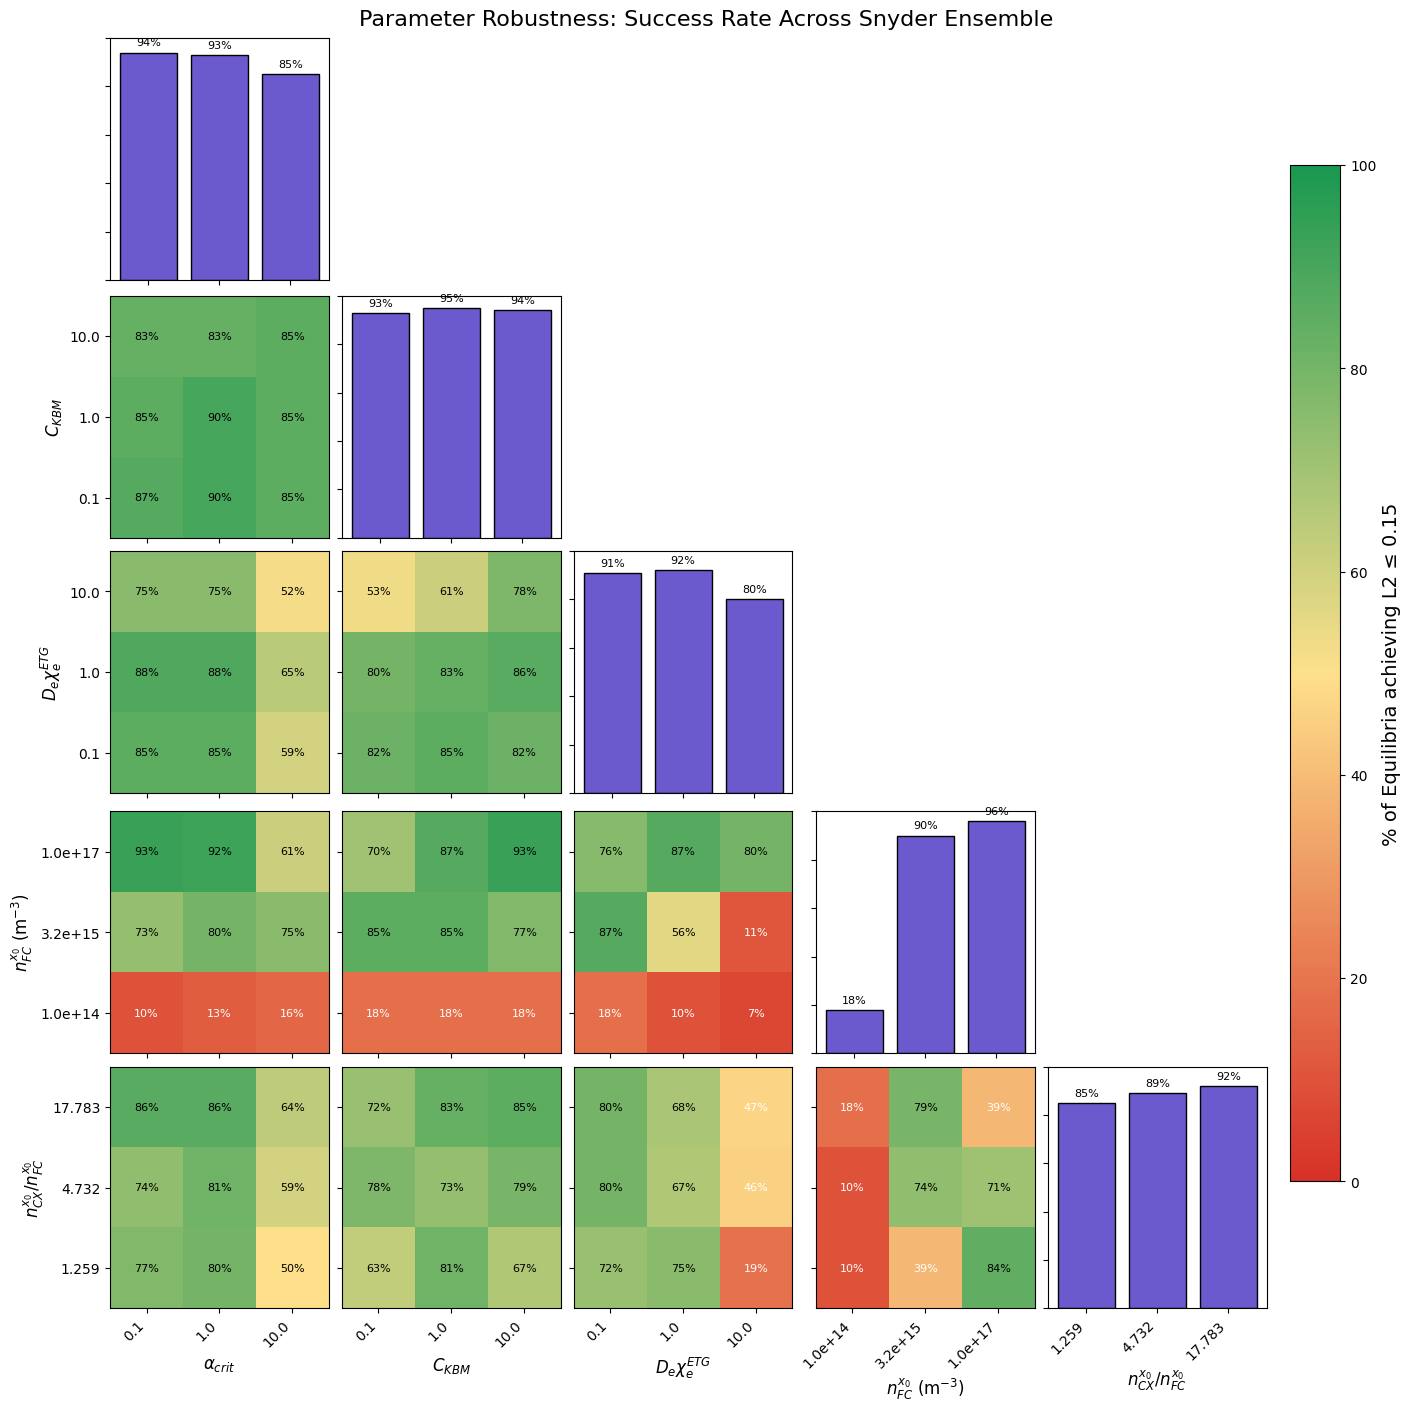

In [11]:
# Robustness heatmap: % of equilibria achieving L2 ≤ L2_THRESHOLD
# for each parameter (diagonal) / parameter pair (lower triangle).
# Counts unique equilibria per bin (not individual runs).

L2_THRESHOLD = 0.15

param_names = [
    r"$\alpha_{crit}$",
    r"$C_{KBM}$",
    r"$D_e\chi_e^{ETG}$",
    r"$n_{FC}^{x_0}$ (m$^{-3}$)",
    r"$n_{CX}^{x_0}/n_{FC}^{x_0}$",
]
colors = ["#d73027", "#fee08b", "#1a9850"]
rd_gn_cmap = LinearSegmentedColormap.from_list("RdYlGn_custom", colors)

all_runs = []
unique_params = [set() for _ in range(5)]
parsed_eq_tags = set()

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue
    parsed_eq_tags.add(eq_tag)
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            try:
                _, ac, ck, de, nf, nc, psi_b, l2_err = [x.strip() for x in row[:8]]
                ac, ck, de = round(float(ac), 3), round(float(ck), 3), round(float(de), 3)
                nf, nc = float(nf), float(nc)
                vals = [ac, ck, de, nf, nc]
                l2_err = float(l2_err)
            except ValueError:
                continue
            all_runs.append((eq_tag, vals, l2_err))
            for i in range(5):
                unique_params[i].add(vals[i])

param_grids = [sorted(list(u)) for u in unique_params]
parsed_eq_count = len(parsed_eq_tags)
print(f"Parsed {parsed_eq_count} equilibria and {len(all_runs)} total runs.")
print("Dynamically discovered parameter grids:")
for name, grid in zip(param_names, param_grids):
    print(f"  {name}: {grid}")

success_sets = [[[[set() for _ in range(len(param_grids[j]))]
                         for _ in range(len(param_grids[i]))]
                         for j in range(5)]
                         for i in range(5)]

def get_grid_idx(val, grid):
    return (np.abs(np.array(grid) - val)).argmin()

for eq_tag, vals, l2_err in all_runs:
    if l2_err <= L2_THRESHOLD:
        idx = [get_grid_idx(v, g) for v, g in zip(vals, param_grids)]
        for i in range(5):
            for j in range(5):
                success_sets[i][j][idx[i]][idx[j]].add(eq_tag)

fig, axes = plt.subplots(5, 5, figsize=(14, 14), constrained_layout=True)
cmap = rd_gn_cmap
norm = Normalize(vmin=0, vmax=100)

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        n_rows = len(param_grids[i])
        n_cols = len(param_grids[j])
        if j > i:
            ax.axis("off")
            continue

        matrix_pct = np.zeros((n_rows, n_cols))
        for v1 in range(n_rows):
            for v2 in range(n_cols):
                success_count = len(success_sets[i][j][v1][v2])
                matrix_pct[v1, v2] = (success_count / parsed_eq_count) * 100

        if i == j:
            diag_pct = np.diag(matrix_pct)
            ax.bar(range(n_cols), diag_pct, color="slateblue", edgecolor="k")
            ax.set_ylim(0, 100)
            ax.set_xticks(range(n_cols))
            labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[i]]
            ax.set_xticklabels(labels, rotation=45, ha="right")
            for bar_idx, pct in enumerate(diag_pct):
                ax.text(bar_idx, pct + 2, f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)
        else:
            ax.imshow(matrix_pct, cmap=cmap, norm=norm, origin="lower", aspect="auto")
            ax.set_xticks(range(n_cols))
            ax.set_yticks(range(n_rows))
            x_labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[j]]
            y_labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[i]]
            ax.set_xticklabels(x_labels, rotation=45, ha="right")
            ax.set_yticklabels(y_labels)
            for v1 in range(n_rows):
                for v2 in range(n_cols):
                    pct = matrix_pct[v1, v2]
                    text_color = "white" if pct < 50 else "black"
                    ax.text(v2, v1, f"{pct:.0f}%", ha="center", va="center",
                            color=text_color, fontsize=8)

        if i == 4:
            ax.set_xlabel(param_names[j], fontsize=12)
        else:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(param_names[i], fontsize=12)
        else:
            ax.set_yticklabels([])

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, location="right", pad=0.02)
cbar.set_label(f"% of Equilibria achieving L2 ≤ {L2_THRESHOLD}", fontsize=14)
plt.suptitle("Parameter Robustness: Success Rate Across Snyder Ensemble", fontsize=16)
plt.show()
